# Vehicle Detection Dataset EDA and System Design

This notebook performs end-to-end exploratory data analysis on the Vehicle Detection Image Dataset (Kaggle: pkdarabi), consolidates annotations into a unified detection format, summarizes dataset characteristics, and defines a directly implementable preprocessing and vehicle detection-counting pipeline.

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## Data Loading and Parsing

The dataset is expected to be arranged in YOLO-style splits with paired `images/` and `labels/` directories under each split (`train`, `valid`, `test`). Annotation files store one object per line in normalized YOLO format: `class_id x_center y_center width height`. These normalized values are converted to absolute `xyxy` pixel coordinates for unified downstream processing.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_root = '/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main'
# Class map (consistent with dataset export)
CLASS_NAMES = ['Bus', 'Car', 'Motorcycle', 'Truck']
CLASS_MAP = {i: n for i, n in enumerate(CLASS_NAMES)}

def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2.0) * img_w
    y1 = (yc - h / 2.0) * img_h
    x2 = (xc + w / 2.0) * img_w
    y2 = (yc + h / 2.0) * img_h
    return x1, y1, x2, y2

def parse_single_sample(image_path):
    label_path = image_path.replace(os.sep + 'images' + os.sep, os.sep + 'labels' + os.sep)
    label_path = os.path.splitext(label_path)[0] + '.txt'

    bgr = cv2.imread(image_path)
    if bgr is None:
        raise ValueError(f'Failed to read image: {image_path}')
    image = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]

    boxes, labels = [], []
    if os.path.exists(label_path):
        with open(label_path, 'r', encoding='utf-8') as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]
        for ln in lines:
            c, xc, yc, w, h = ln.split()
            c = int(float(c))
            xc, yc, w, h = map(float, (xc, yc, w, h))
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, img_w, img_h)
            x1 = np.clip(x1, 0, img_w - 1)
            y1 = np.clip(y1, 0, img_h - 1)
            x2 = np.clip(x2, 0, img_w - 1)
            y2 = np.clip(y2, 0, img_h - 1)
            boxes.append([x1, y1, x2, y2])
            labels.append(c)

    sample = {
        'image': image,
        'boxes': np.array(boxes, dtype=np.float32).reshape(-1, 4) if len(boxes) else np.zeros((0, 4), dtype=np.float32),
        'labels': np.array(labels, dtype=np.int64),
    }
    return sample

splits = ['train', 'valid', 'test']
image_paths = []
structure_summary = {}

for sp in splits:
    img_dir = os.path.join(dataset_root, sp, 'images')
    lbl_dir = os.path.join(dataset_root, sp, 'labels')
    imgs = []
    if os.path.isdir(img_dir):
        imgs = [os.path.join(img_dir, fn) for fn in os.listdir(img_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]
    imgs = sorted(imgs)
    labels = sorted([fn for fn in os.listdir(lbl_dir)]) if os.path.isdir(lbl_dir) else []
    structure_summary[sp] = {
        'image_dir': img_dir,
        'label_dir': lbl_dir,
        'num_images': len(imgs),
        'num_label_files': len(labels),
    }
    image_paths.extend(imgs)

print(json.dumps(structure_summary, indent=2))
print('Class mapping:', CLASS_MAP)
print('Total discovered images:', len(image_paths))

# Parsed example in unified format
example = parse_single_sample(image_paths[0])
print('\nUnified sample keys:', example.keys())
print('image shape:', example['image'].shape)
print('boxes shape:', example['boxes'].shape)
print('labels shape:', example['labels'].shape)

{
  "train": {
    "image_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/images",
    "label_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/labels",
    "num_images": 800,
    "num_label_files": 800
  },
  "valid": {
    "image_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/valid/images",
    "label_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/valid/labels",
    "num_images": 100,
    "num_label_files": 100
  },
  "test": {
    "image_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images",
    "label_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/labels",
    "num_images": 100,
    "num_label_files": 100
  }
}
Class mapping: {0: 'Bus', 1: 'Car', 2: 'Motorcycle', 3: 'Truck'}
Total discovered images: 1000

Unified sample keys: dict_keys(['image', 'boxes', 'labels'])
image shape: (640, 640, 3)
boxes shape: (13, 4)
labels shape: (13,)


## Data Visualization

In [4]:
import random

def draw_boxes_rgb(image_rgb, boxes, labels, class_map):
    canvas = image_rgb.copy()
    for box, lb in zip(boxes, labels):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cls_name = class_map.get(int(lb), str(lb))
        cv2.putText(canvas, cls_name, (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)
    return canvas

sample_bank = []
for p in image_paths:
    s = parse_single_sample(p)
    if s['boxes'].shape[0] > 0:
        sample_bank.append((p, s, s['boxes'].shape[0]))

viz_samples = random.sample(sample_bank, 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (path_i, sample_i, n_i) in enumerate(viz_samples):
    drawn = draw_boxes_rgb(sample_i['image'], sample_i['boxes'], sample_i['labels'], CLASS_MAP)
    axes[i].imshow(drawn)
    axes[i].set_title(f"Objects: {n_i}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/sample_images.png')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## EDA

In [5]:
objects_per_image = []
class_counts = {i: 0 for i in CLASS_MAP.keys()}
bbox_w, bbox_h, bbox_area = [], [], []
bbox_rel_area = []

noise_flags = {
    'missing_label_file': 0,
    'empty_label_file': 0,
    'invalid_class_id': 0,
    'nonpositive_box': 0,
    'out_of_bounds_box': 0,
}

for p in image_paths:
    label_path = p.replace(os.sep + 'images' + os.sep, os.sep + 'labels' + os.sep)
    label_path = os.path.splitext(label_path)[0] + '.txt'

    bgr = cv2.imread(p)
    if bgr is None:
        objects_per_image.append(0)
        continue

    img_h, img_w = bgr.shape[:2]

    if not os.path.exists(label_path):
        noise_flags['missing_label_file'] += 1
        objects_per_image.append(0)
        continue

    with open(label_path, 'r', encoding='utf-8') as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    if len(lines) == 0:
        noise_flags['empty_label_file'] += 1
        objects_per_image.append(0)
        continue

    n_obj = 0
    for ln in lines:
        parts = ln.split()
        if len(parts) != 5:
            continue

        cls_id, xc, yc, w, h = parts
        cls_id = int(float(cls_id))
        xc, yc, w, h = map(float, (xc, yc, w, h))

        if cls_id not in class_counts:
            noise_flags['invalid_class_id'] += 1
            continue

        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, img_w, img_h)
        bw = x2 - x1
        bh = y2 - y1

        if bw <= 0 or bh <= 0:
            noise_flags['nonpositive_box'] += 1
            continue

        if x1 < 0 or y1 < 0 or x2 > img_w or y2 > img_h:
            noise_flags['out_of_bounds_box'] += 1

        area = bw * bh
        bbox_w.append(bw)
        bbox_h.append(bh)
        bbox_area.append(area)
        bbox_rel_area.append(area / float(img_w * img_h))

        class_counts[cls_id] += 1
        n_obj += 1

    objects_per_image.append(n_obj)

objects_per_image = np.array(objects_per_image, dtype=np.int32)
bbox_w = np.array(bbox_w, dtype=np.float32)
bbox_h = np.array(bbox_h, dtype=np.float32)
bbox_area = np.array(bbox_area, dtype=np.float32)
bbox_rel_area = np.array(bbox_rel_area, dtype=np.float32)

total_images = len(image_paths)
total_objects = int(objects_per_image.sum())
avg_objects_per_image = float(objects_per_image.mean())
median_objects_per_image = float(np.median(objects_per_image))
max_objects_per_image = int(objects_per_image.max())
zero_object_images = int((objects_per_image == 0).sum())

bbox_stats = {
    'width_px': {
        'mean': float(bbox_w.mean()),
        'median': float(np.median(bbox_w)),
        'min': float(bbox_w.min()),
        'max': float(bbox_w.max()),
        'p10': float(np.percentile(bbox_w, 10)),
        'p90': float(np.percentile(bbox_w, 90)),
    },
    'height_px': {
        'mean': float(bbox_h.mean()),
        'median': float(np.median(bbox_h)),
        'min': float(bbox_h.min()),
        'max': float(bbox_h.max()),
        'p10': float(np.percentile(bbox_h, 10)),
        'p90': float(np.percentile(bbox_h, 90)),
    },
    'area_px2': {
        'mean': float(bbox_area.mean()),
        'median': float(np.median(bbox_area)),
        'min': float(bbox_area.min()),
        'max': float(bbox_area.max()),
        'p10': float(np.percentile(bbox_area, 10)),
        'p90': float(np.percentile(bbox_area, 90)),
    },
}

small_object_fraction = {
    'area_lt_32x32': float((bbox_area < 32 * 32).mean()),
    'area_lt_16x16': float((bbox_area < 16 * 16).mean()),
    'relative_area_lt_1pct': float((bbox_rel_area < 0.01).mean()),
    'relative_area_lt_0_5pct': float((bbox_rel_area < 0.005).mean()),
}

class_distribution_named = {CLASS_MAP[k]: int(v) for k, v in class_counts.items()}

eda_summary = {
    'dataset_root': dataset_root,
    'split_structure': structure_summary,
    'class_map': CLASS_MAP,
    'total_images': total_images,
    'total_objects': total_objects,
    'avg_objects_per_image': avg_objects_per_image,
    'median_objects_per_image': median_objects_per_image,
    'max_objects_per_image': max_objects_per_image,
    'zero_object_images': zero_object_images,
    'class_distribution': class_distribution_named,
    'bbox_stats': bbox_stats,
    'small_object_fraction': small_object_fraction,
    'noise_flags': noise_flags,
}

os.makedirs('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda', exist_ok=True)
with open('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/summary.json', 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, indent=2)

print(json.dumps(eda_summary, indent=2))

{
  "dataset_root": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main",
  "split_structure": {
    "train": {
      "image_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/images",
      "label_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/labels",
      "num_images": 800,
      "num_label_files": 800
    },
    "valid": {
      "image_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/valid/images",
      "label_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/valid/labels",
      "num_images": 100,
      "num_label_files": 100
    },
    "test": {
      "image_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images",
      "label_dir": "/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/labels",
      "num_images": 100,
      "num_label_files": 100
    }
  },
  "class_map": {
    "0": "Bus",
    "1": "Car",
    "2": "Motorcycle",
    "3": 

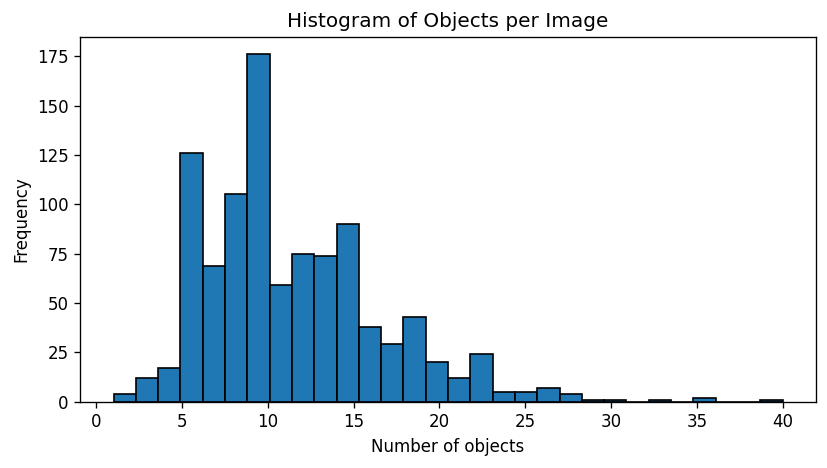

In [6]:
# Plots required by EDA
plt.figure(figsize=(7, 4))
bins = min(30, max(6, int(objects_per_image.max()) + 1))
plt.hist(objects_per_image, bins=bins, edgecolor='black')
plt.title('Histogram of Objects per Image')
plt.xlabel('Number of objects')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/object_per_image.png')
plt.show()


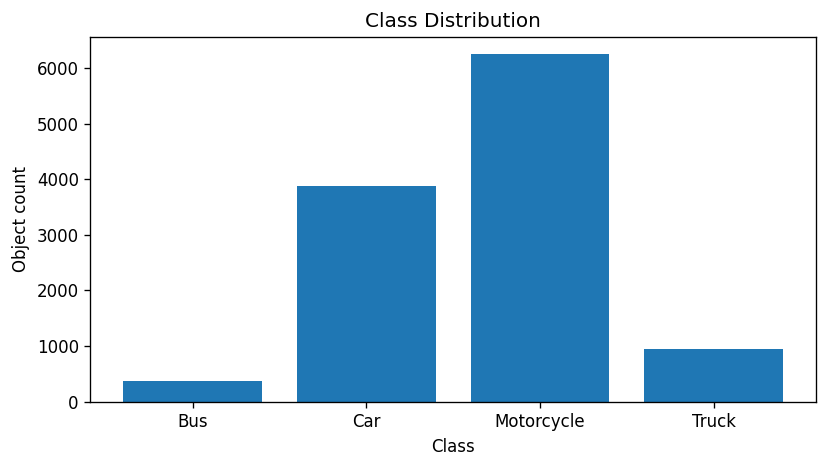

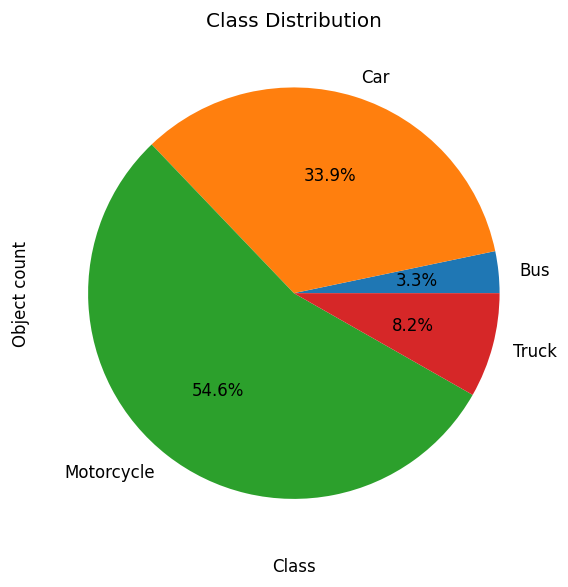

In [7]:

plt.figure(figsize=(7, 4))
cls_names = list(class_distribution_named.keys())
cls_vals = list(class_distribution_named.values())
plt.bar(cls_names, cls_vals)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Object count')
plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/bar_class_distribution.png')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.pie(cls_vals, labels=cls_names, autopct="%1.1f%%")
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Object count')
plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/pie_class_distribution.png')
plt.tight_layout()
plt.show()


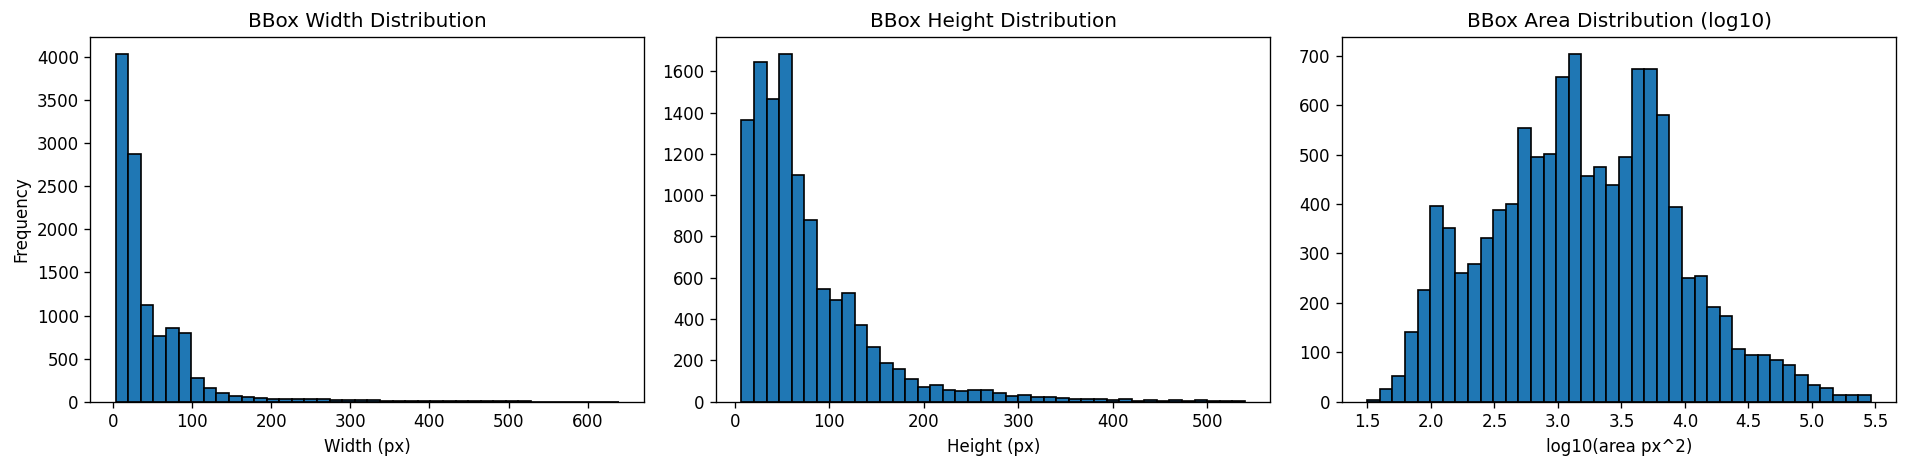

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(bbox_w, bins=40, edgecolor='black')
axes[0].set_title('BBox Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Frequency')

axes[1].hist(bbox_h, bins=40, edgecolor='black')
axes[1].set_title('BBox Height Distribution')
axes[1].set_xlabel('Height (px)')

axes[2].hist(np.log10(np.maximum(bbox_area, 1e-6)), bins=40, edgecolor='black')
axes[2].set_title('BBox Area Distribution (log10)')
axes[2].set_xlabel('log10(area px^2)')

plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/bbox_size_distribution.png')
plt.tight_layout()
plt.show()

### Visualizing Characteristic Images

In [9]:
# Initialize variables for finding specific images
max_objects_count = -1
max_objects_sample_data = None
max_objects_path = None

min_objects_count_nonzero = float('inf')
min_objects_sample_data_nonzero = None
min_objects_path_nonzero = None

largest_bbox_area = -1.0
largest_bbox_sample_data = None
largest_bbox_path = None
largest_bbox_label = None

smallest_bbox_area = float('inf')
smallest_bbox_sample_data = None
smallest_bbox_path = None
smallest_bbox_label = None


# Loop through all image paths to find the characteristic images
for p in image_paths:
    sample = parse_single_sample(p)
    num_objects = sample['boxes'].shape[0]

    # Find image with most objects
    if num_objects > max_objects_count:
        max_objects_count = num_objects
        max_objects_sample_data = sample
        max_objects_path = p

    # Find image with least objects (all images have objects based on EDA summary,
    # so we look for the minimum non-zero count)
    if num_objects > 0 and num_objects < min_objects_count_nonzero:
        min_objects_count_nonzero = num_objects
        min_objects_sample_data_nonzero = sample
        min_objects_path_nonzero = p

    # Find images with largest/smallest individual bounding box
    for idx, box in enumerate(sample['boxes']):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        area = width * height

        if area > largest_bbox_area:
            largest_bbox_area = area
            largest_bbox_sample_data = sample
            largest_bbox_path = p
            largest_bbox_label = sample['labels'][idx]

        if area < smallest_bbox_area:
            smallest_bbox_area = area
            smallest_bbox_sample_data = sample
            smallest_bbox_path = p
            smallest_bbox_label = sample['labels'][idx]

# Prepare samples for visualization, ensuring they are not None
samples_to_display = []
titles_to_display = []

if max_objects_sample_data is not None:
    samples_to_display.append(max_objects_sample_data)
    titles_to_display.append(f"Image with Most Objects ({max_objects_count})")

if min_objects_sample_data_nonzero is not None:
    samples_to_display.append(min_objects_sample_data_nonzero)
    titles_to_display.append(f"Image with Least Objects ({min_objects_count_nonzero})")

if largest_bbox_sample_data is not None:
    samples_to_display.append(largest_bbox_sample_data)
    titles_to_display.append(f"Image with Largest BBox (Area: {largest_bbox_area:.1f}, Class: {CLASS_MAP.get(int(largest_bbox_label), 'Unknown')})")

if smallest_bbox_sample_data is not None:
    samples_to_display.append(smallest_bbox_sample_data)
    titles_to_display.append(f"Image with Smallest BBox (Area: {smallest_bbox_area:.1f}, Class: {CLASS_MAP.get(int(smallest_bbox_label), 'Unknown')})")

# Display the identified images
num_plots = len(samples_to_display)
if num_plots > 0:
    fig, axes = plt.subplots((num_plots + 1) // 2, 2, figsize=(12, 5 * ((num_plots + 1) // 2)))
    axes = axes.flatten()

    for i, sample_data in enumerate(samples_to_display):
        drawn_image = draw_boxes_rgb(sample_data['image'], sample_data['boxes'], sample_data['labels'], CLASS_MAP)
        axes[i].imshow(drawn_image)
        axes[i].set_title(titles_to_display[i])
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/identified_characteristic_images.png')
    plt.show()
else:
    print("Could not find sufficient characteristic images to display.")

Output hidden; open in https://colab.research.google.com to view.

### Further EDA Suggestions

Here are some additional exploratory data analysis steps that could be beneficial:

1.  **Bounding Box Aspect Ratio Distribution:** Analyze the distribution of width-to-height ratios of bounding boxes. This can provide insights into the typical shapes of vehicles and help in designing appropriate anchor boxes for object detection models.

2.  **Object Density Heatmaps:** Create heatmaps to visualize the spatial distribution of object centers across images. This can reveal if objects are more concentrated in certain regions (e.g., lower half of the image for road scenes), which might influence model architecture or attention mechanisms.

3.  **Image Resolution Distribution (if applicable):** If the dataset contains images of varying resolutions, analyze their distribution. This is crucial for determining resizing strategies during preprocessing.

4.  **Class Distribution Across Splits:** Verify the class balance within `train`, `valid`, and `test` splits. An imbalanced distribution across splits can lead to biased model training or evaluation results.

5.  **Small Object Analysis:** Given the `small_object_fraction` statistics, a more detailed analysis of very small objects could be useful, perhaps visualizing examples of these objects and considering strategies for their detection.

### Additional Characteristic Image Visualizations

In [15]:
def calculate_iou(boxA, boxB):
    # Determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Compute the area of intersection rectangle
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # Compute the area of both the prediction and ground-truth rectangles
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Compute the intersection over union by dividing the intersection area
    # by the sum of prediction + ground-truth areas - the interesection area
    iou = interArea / float(boxAArea + boxBArea - interArea)

    return iou

def check_for_overlaps(boxes, iou_threshold=0.5):
    if len(boxes) < 2:
        return False
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            if calculate_iou(boxes[i], boxes[j]) > iou_threshold:
                return True
    return False

def calculate_blur_metric(image):
    # Convert to grayscale for blur detection
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # Compute the Laplacian variance, which is a measure of blur
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_brightness_metric(image):
    # Convert to HSV and take the V (Value) channel for brightness
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    return np.mean(hsv[:, :, 2])

# Initialize variables for finding specific images
overlap_images = []
blur_metrics = [] # Store (blur_value, image_path, sample_data)
brightness_metrics = [] # Store (brightness_value, image_path, sample_data)

for p in image_paths:
    sample = parse_single_sample(p)

    # Check for overlapping bounding boxes
    if sample['boxes'].shape[0] > 0 and check_for_overlaps(sample['boxes'], iou_threshold=0.3):
        overlap_images.append((p, sample))

    # Calculate blur metric
    blur_val = calculate_blur_metric(sample['image'])
    blur_metrics.append((blur_val, p, sample))

    # Calculate brightness metric
    brightness_val = calculate_brightness_metric(sample['image'])
    brightness_metrics.append((brightness_val, p, sample))

# Sort metrics to find extremes
blur_metrics.sort(key=lambda x: x[0]) # Smallest blur first
brightness_metrics.sort(key=lambda x: x[0]) # Darkest first

# Select characteristic images
viz_characteristics = {
    'Overlapping BBoxes': overlap_images[0] if overlap_images else None,
    'Most Blurred Image': blur_metrics[0] if blur_metrics else None,
    'Least Blurred Image': blur_metrics[-1] if blur_metrics else None, # Highest blur value (least blurry)
    'Darkest Image': brightness_metrics[0] if brightness_metrics else None,
    'Brightest Image': brightness_metrics[-1] if brightness_metrics else None,
}

# Display the identified characteristic images
num_plots = sum(1 for v in viz_characteristics.values() if v is not None)
if num_plots > 0:
    fig, axes = plt.subplots((num_plots + 1) // 2, 2, figsize=(12, 5 * ((num_plots + 1) // 2)))
    axes = axes.flatten()
    plot_idx = 0

    for title, data in viz_characteristics.items():
        if data:
            path, sample_data = data[0], data[1] # For overlap_images it's (path, sample), for metrics it's (metric_val, path, sample)
            if len(data) == 3: # If it's from blur_metrics or brightness_metrics
                 metric_val, path, sample_data = data
                 if 'Blurred' in title:
                     title = f"{title} (Blur: {metric_val:.2f})"
                 elif 'Image' in title:
                     title = f"{title} (Brightness: {metric_val:.2f})"

            drawn_image = draw_boxes_rgb(sample_data['image'], sample_data['boxes'], sample_data['labels'], CLASS_MAP)
            axes[plot_idx].imshow(drawn_image)
            axes[plot_idx].set_title(title)
            axes[plot_idx].axis('off')
            plot_idx += 1

    # Hide any unused subplots
    for j in range(plot_idx, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/additional_characteristic_images.png')
    plt.show()
else:
    print("Could not find sufficient additional characteristic images to display.")

Output hidden; open in https://colab.research.google.com to view.

### Object Density Heatmap

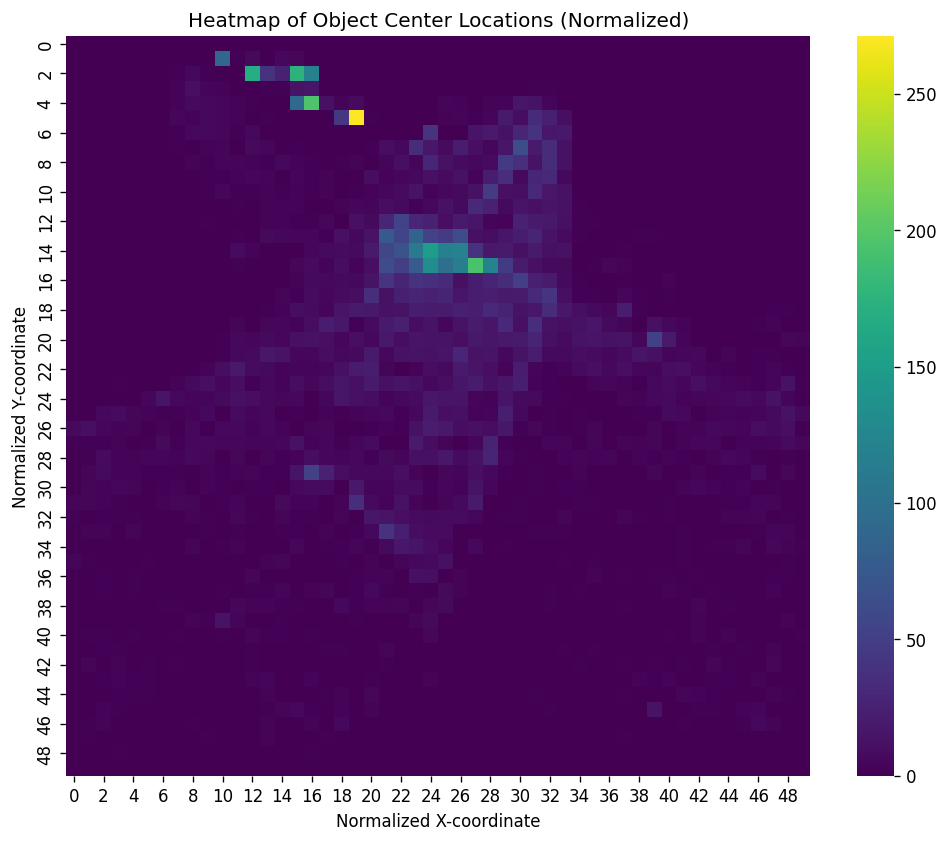

In [13]:
import seaborn as sns
# Collect all object center coordinates
all_cx, all_cy = [], []

for p in image_paths:
    sample = parse_single_sample(p)
    img_h, img_w = sample['image'].shape[:2]

    if sample['boxes'].shape[0] > 0:
        # Convert xyxy to cxcywh for centers
        x1, y1, x2, y2 = sample['boxes'].T
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0

        all_cx.extend(cx / img_w) # Normalize x to [0, 1]
        all_cy.extend(cy / img_h) # Normalize y to [0, 1]

# Create a 2D histogram (heatmap data)
# Use 50 bins for a decent resolution heatmap
hist, xedges, yedges = np.histogram2d(all_cx, all_cy, bins=50, range=[[0, 1], [0, 1]])

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(hist.T, cmap='viridis')
plt.title('Heatmap of Object Center Locations (Normalized)')
plt.xlabel('Normalized X-coordinate')
plt.ylabel('Normalized Y-coordinate')
plt.grid(False)
plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/object_density_heatmap.png')
plt.show()

### Class Distribution Across Splits


Class Distribution for TRAIN Split:
  Bus: 295
  Car: 3137
  Motorcycle: 5007
  Truck: 755

Class Distribution for VALID Split:
  Bus: 37
  Car: 366
  Motorcycle: 611
  Truck: 93

Class Distribution for TEST Split:
  Bus: 43
  Car: 369
  Motorcycle: 628
  Truck: 93


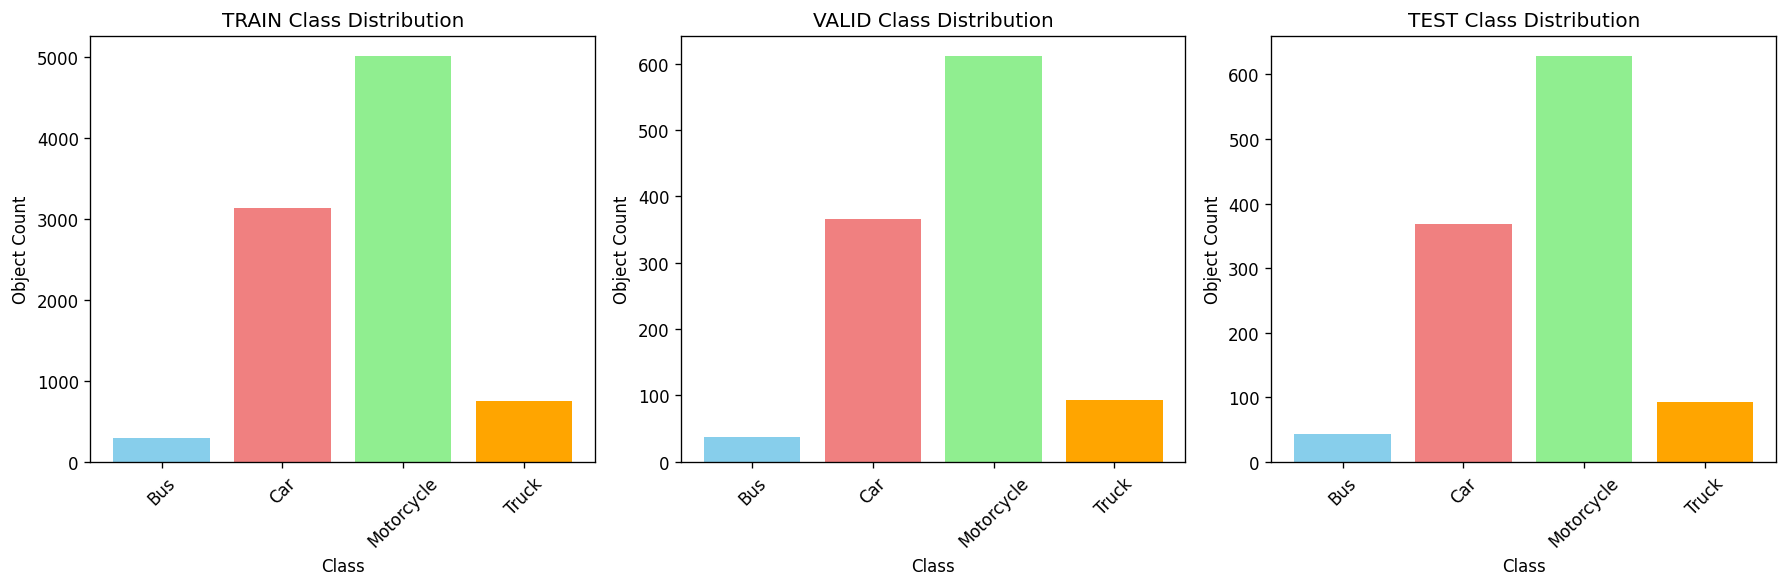

In [14]:
split_class_distributions = {}

for sp in splits:
    split_image_paths = sorted([os.path.join(dataset_root, sp, 'images', fn) for fn in os.listdir(os.path.join(dataset_root, sp, 'images')) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))])
    current_split_class_counts = {k: 0 for k in CLASS_MAP.keys()}

    for p in split_image_paths:
        label_path = p.replace(os.sep + 'images' + os.sep, os.sep + 'labels' + os.sep)
        label_path = os.path.splitext(label_path)[0] + '.txt'

        if os.path.exists(label_path):
            with open(label_path, 'r', encoding='utf-8') as f:
                lines = [ln.strip() for ln in f.readlines() if ln.strip()]

            for ln in lines:
                parts = ln.split()
                if len(parts) == 5:
                    cls_id = int(float(parts[0]))
                    if cls_id in current_split_class_counts:
                        current_split_class_counts[cls_id] += 1

    split_class_distributions[sp] = {CLASS_MAP[k]: v for k, v in current_split_class_counts.items()}

# Display the distributions
for sp, dist in split_class_distributions.items():
    print(f"\nClass Distribution for {sp.upper()} Split:")
    for class_name, count in dist.items():
        print(f"  {class_name}: {count}")

# Optional: Visualize as bar charts
num_splits = len(split_class_distributions)
fig, axes = plt.subplots(1, num_splits, figsize=(5 * num_splits, 5))
axes = axes.flatten() if num_splits > 1 else [axes]

for i, (sp, dist) in enumerate(split_class_distributions.items()):
    class_names = list(dist.keys())
    class_counts = list(dist.values())
    axes[i].bar(class_names, class_counts, color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
    axes[i].set_title(f'{sp.upper()} Class Distribution')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Object Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/eda/split_class_distribution.png')
plt.show()